[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01      675.32      683.15      673.49      679.08    14004468
2020-01-02      686.82      689.35      676.40      676.40    17710316
2020-01-03      687.65      689.66      681.32      685.79    20984698
2020-01-06      671.70      683.51      670.13      679.98    24519177
2020-01-07      682.03      686.46      677.07      679.53    16683622


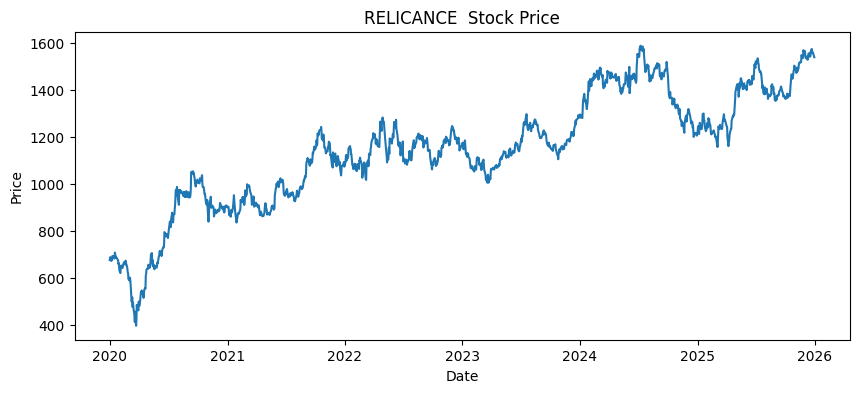

X shape: (1483, 3)
y shape: (1483,)
[1353.5  1363.23 1338.34 1332.19 1333.97 1322.49 1328.28 1334.43 1338.3
 1326.73 1332.55 1297.52 1298.79 1319.57 1301.12 1278.28 1267.08 1268.74
 1247.44 1261.6  1256.24 1236.83 1217.96 1259.11 1282.62 1290.86 1288.18
 1265.93 1285.92 1304.07 1318.03 1304.15 1315.9  1306.64 1289.77 1279.29
 1272.81 1257.86 1267.1  1263.54 1240.58 1247.46 1226.2  1200.39 1216.54
 1218.46 1211.93 1216.04 1206.31 1210.36]
RMSE: 16.42
Accuracy :  99.08
Error :  0.92


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("RELIANCE.NS", start="2020-01-01", end="2025-12-31")

print(data.head().round(2))

plt.figure(figsize=(10,4))
plt.plot(data['Close'])
plt.title("RELICANCE  Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()
import numpy as np

close_data = data['Close'].values

X = []
y = []

window_size = 3 

for i in range(len(close_data) - window_size):
    X.append(close_data[i:i+window_size])
    y.append(close_data[i+window_size])

X = np.array(X)
y = np.array(y)

X=X.reshape(X.shape[0],X.shape[1])
y=y.ravel()
print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:50].round(2))
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("RMSE:", rmse.round(2))
errorPercentage = np.mean(np.abs((predictions-y_test)/y_test))*100
print("Accuracy : ",100-errorPercentage.round(2))
print("Error : ", errorPercentage.round(2))